In [1]:
from sae import SAE
import clip
import json
import os
import pandas as pd
from tqdm import tqdm
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sae1 = SAE("models/4096_512_TopKReLU_64_False_False_0.0_cc3m_ViT-B~16_train_image_2905954_512_None_42.pth").cuda()
sae2 = SAE("models/4096_512_TopKReLU_64_False_False_0.0_cc3m_ViT-B~16_train_image_2905954_512_DcorTopLatent_42.pth").cuda()
clip_model, clip_prep = clip.load("ViT-B/16", device="cuda")

In [3]:
with open('imagenet100/Labels.json', 'r') as f:
    labels = json.load(f)

In [4]:
images = []

for label in os.listdir('imagenet100/val.X'):
    for filename in os.listdir(f'imagenet100/val.X/{label}'):
        images.append({
            'path': f'imagenet100/val.X/{label}/{filename}',
            'label': labels[label],
        })

df = pd.DataFrame(images)
df

,path,label
0,imagenet100/val.X/n01687978/ILSVRC2012_val_000...,agama
1,imagenet100/val.X/n01687978/ILSVRC2012_val_000...,agama
2,imagenet100/val.X/n01687978/ILSVRC2012_val_000...,agama
3,imagenet100/val.X/n01687978/ILSVRC2012_val_000...,agama
4,imagenet100/val.X/n01687978/ILSVRC2012_val_000...,agama
...,...,...
4995,imagenet100/val.X/n01739381/ILSVRC2012_val_000...,vine snake
4996,imagenet100/val.X/n01739381/ILSVRC2012_val_000...,vine snake
4997,imagenet100/val.X/n01739381/ILSVRC2012_val_000...,vine snake
4998,imagenet100/val.X/n01739381/ILSVRC2012_val_000...,vine snake


In [5]:
sae1_representations = []
sae2_representations = []
clip_representations = []
sae1_reconstructed = []
sae2_reconstructed = []
image_paths = []
metrics_all = []

for index, row in tqdm(df.iterrows(), total=len(df)):
    image_paths.append(row['path'])
    image = Image.open(row['path'])
    input = clip_prep(image).unsqueeze(0)

    with torch.no_grad():
        features = clip_model.encode_image(input.to('cuda'))
        post_reconstructed1, reconstructed1, full_latents1 = sae1(features.to(torch.float32).to('cuda'))
        recon, lat, full_rec, full_lat = sae1.model(features.to(torch.float32).to('cuda'))
        post_reconstructed2, reconstructed2, full_latents2 = sae2(features.to(torch.float32).to('cuda'))
        
    clip_representations.append(features.cpu().flatten())
    sae1_representations.append(full_latents1.cpu().flatten())
    sae2_representations.append(full_latents2.cpu().flatten())
    sae1_reconstructed.append(post_reconstructed1.cpu().flatten())
    sae2_reconstructed.append(post_reconstructed2.cpu().flatten())

clip_representations = torch.stack(clip_representations)
sae1_representations = torch.stack(sae1_representations)
sae2_representations = torch.stack(sae2_representations)
sae1_reconstructed = torch.stack(sae1_reconstructed)
sae2_reconstructed = torch.stack(sae2_reconstructed)
clip_representations.shape, sae1_representations.shape, sae2_representations.shape

100%|██████████| 5000/5000 [01:22<00:00, 60.51it/s]


(torch.Size([5000, 512]), torch.Size([5000, 4096]), torch.Size([5000, 4096]))

In [6]:
concept_match_scores1 = np.load("namings/Concept_Interpreter_4096_512_TopKReLU_64_False_False_0.0_cc3m_ViT-B~16_train_image_2905954_512_None_42_disect_ViT-B~16_-1_text_20000_512.npy")
concept_match_scores2 = np.load("namings/Concept_Interpreter_4096_512_TopKReLU_64_False_False_0.0_cc3m_ViT-B~16_train_image_2905954_512_DcorTopLatent_42_disect_ViT-B~16_-1_text_20000_512.npy")

In [7]:
with open('vocab/clip_disect_20k.txt', 'r') as f:
    vocab_names = [line.strip() for line in f.readlines()]
len(vocab_names)

20000

In [8]:
img_index1, neuron_index1 = torch.where(sae1_representations == sae1_representations.max())
img_index2, neuron_index2 = torch.where(sae2_representations == sae2_representations.max())

print(f"SAE 1 most active: {neuron_index1.item()} neuron in image {img_index1.item()}")
print(f"SAE 2 most active: {neuron_index2.item()} neuron in image {img_index2.item()}")

SAE 1 most active: 3735 neuron in image 3539
SAE 2 most active: 3687 neuron in image 395


In [9]:
def plot_orthogonality(sae_representations, img_index, conecpt_scores, model, title="SAE 1"):
    fig, ax = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(title)
    k = 10

    with torch.no_grad():
        top_k = sae_representations[img_index].topk(k)
        
        B, d = sae_representations.shape
        expanded = sae_representations[img_index].expand(k, d)
        mask = torch.zeros(k, d, device=sae_representations.device)
        mask[torch.arange(k), top_k.indices] = True

        isolated_concepts = expanded * mask

        decoded_concepts = model.decode(isolated_concepts.cuda())
        decoded_concepts = torch.nn.functional.normalize(decoded_concepts)

        heat_map = decoded_concepts @ decoded_concepts.T
        mean_sim = (heat_map.sum() - k) / (k * (k-1))
        heat_map = heat_map.cpu().numpy()

    names = [vocab_names[conecpt_scores[:, i].argmax()]+f"/{i}" for i in top_k.indices.cpu().numpy()]

    hmap = ax[1].imshow(heat_map, cmap='viridis')
    fig.colorbar(hmap, ax=ax[1])

    ax[1].set_xticks(ticks=range(k), labels=names, rotation=45, ha='right')
    ax[1].set_yticks(ticks=range(k), labels=names)

    ax[1].set_title(f"Cosine Similarity Heatmap - {mean_sim:.4f}")
    
    
    ax[0].imshow(Image.open(image_paths[img_index]).convert('RGB'))
    ax[0].axis('off')
    ax[0].set_title(f'Image {img_index}')
    ax[2].barh(range(k), top_k.values.cpu().numpy())
    ax[2].set_yticks(range(k))
    ax[2].set_yticklabels(names)
    ax[2].set_title(f'Top 10 SAE Concepts for Image {img_index}')
    plt.tight_layout()
    plt.show()

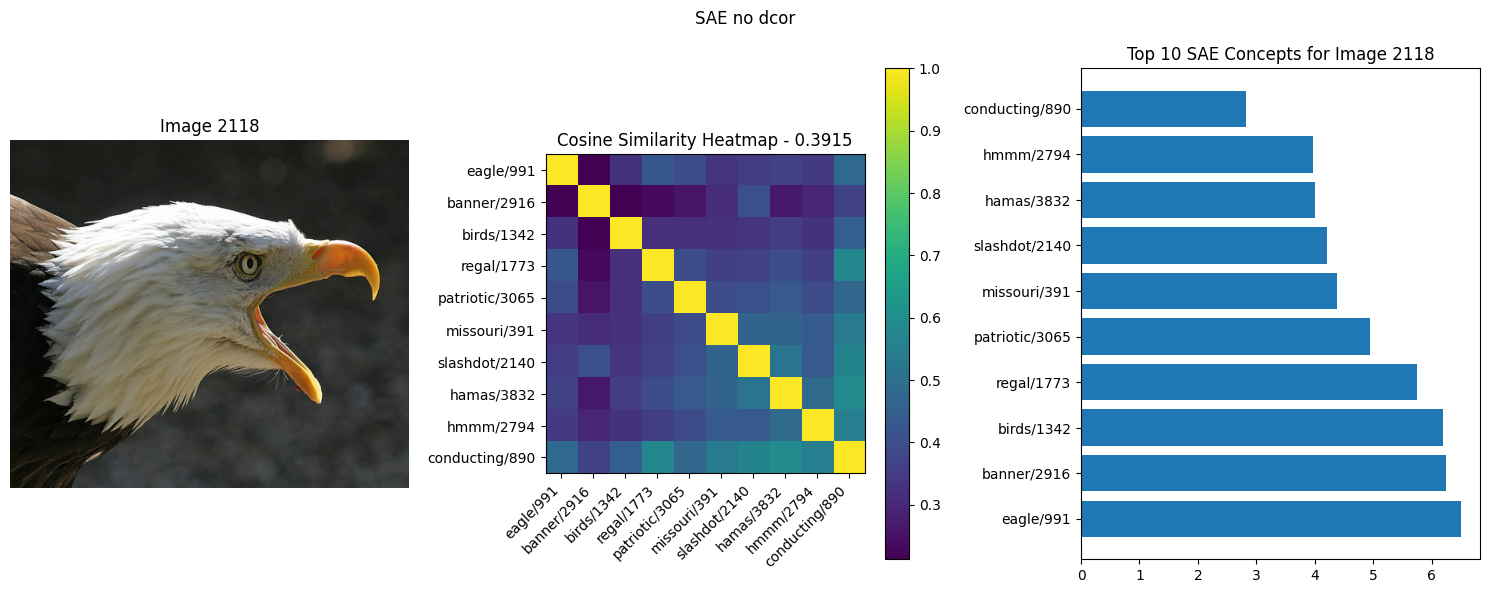

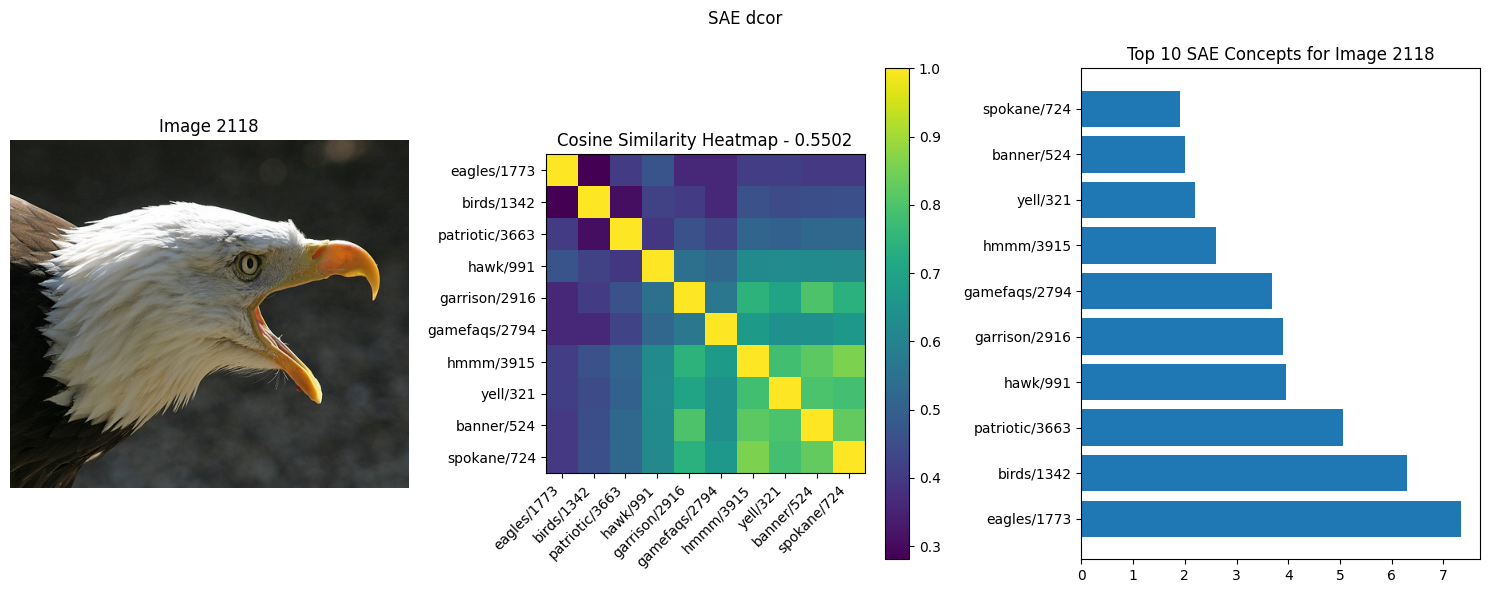

In [26]:
img_index = 2118

plot_orthogonality(sae1_representations, img_index, concept_match_scores1, sae1.model, "SAE no dcor")
plot_orthogonality(sae2_representations, img_index, concept_match_scores2, sae2.model, "SAE dcor")